**1. Motivation**

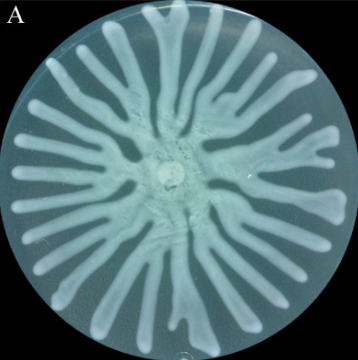
from Bru, J. L. et al. (2023). Swarming of P. aeruginosa: Through the lens of biophysics. Biophysics reviews, 4(3), 031305.

Spatial expansion of bacterial colonies exhibits a variety of growth morphologies, including branching patterns characterized by the emergence of finger-like tendrils. Despite the apparent stochasticity of these structures, their large-scale behavior often reflects underlying physical constraints and symmetry principles.

In this project, we develop an effective stochastic model for colony growth that does not explicitly track individual-level dynamics. Instead, we focus on a coarse-grained description of the evolving colony size as an emergent variable.

Finally, we outline possible extensions that connect the microscopic motion of individual agents to the resulting large-scale emergent behavior.

**2. Model Definition**

Let's start with a simpler picture. Say that I have a biased random-walker who prefers moving strictly in the first quadrant. This single random-walker represents a "tip" in the colony movement, i.e, an outward momentum element. The first challange and the nature of the problem will be clear when we want to have more than one tips.

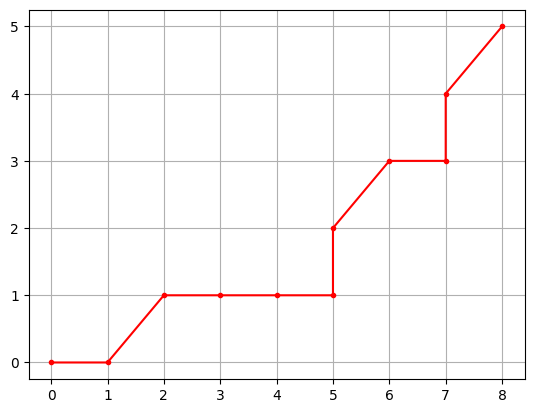

In [2]:
import random
import numpy as np 
import matplotlib.pyplot as plt

bias1=[[1,1],[1,0],[0,1]]

def move(nturn,iloc):
    hist=[iloc]
    locx=iloc[0]
    locy=iloc[1]
    for n in range(1,nturn+1):
        travel=random.choice(bias1)
        locx+=travel[0]
        locy+=travel[1]
        hist.append([locx,locy])
    return np.array(hist)

hist1=move(10,[0,0])

plt.plot(hist1[:,0],hist1[:,1],c='red',marker='.')

plt.grid(True)

Now, let's increase the number of tips by one, and assume that direction of the tips are randomly chosen between two biases: first and second quadrant. In this case, tips may or may not move in the same quadrant. As you can see, this case does not represent a realistic growth pattern. We have experimental evidence that colonies grow almost circularly symmetric manner. Therefore, to have a consistent effective model, I must impose some constraints.

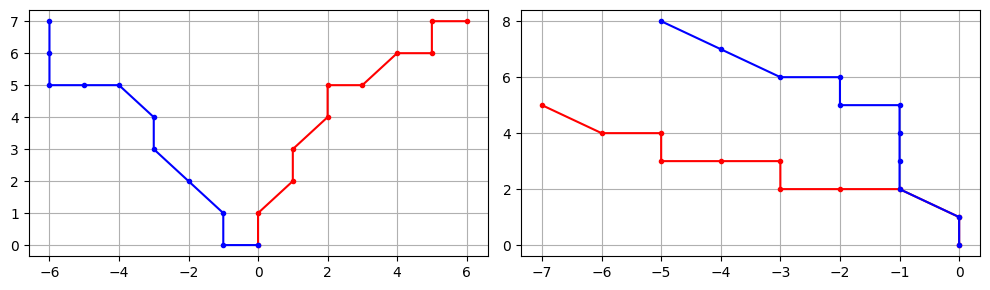

In [3]:
bias1=[[1,1],[1,0],[0,1]]
bias2=[[-1,1],[-1,0],[0,1]]

def move(nturn,iloc):
    hist=[iloc]
    locx=iloc[0]
    locy=iloc[1]
    bias=random.choice([bias1,bias2])
    for n in range(1,nturn+1):
        travel=random.choice(bias)
        locx+=travel[0]
        locy+=travel[1]
        hist.append([locx,locy])
    return np.array(hist)

fig, axs = plt.subplots(1,2,figsize=(10,3))

for i in range(0,2):
    hist1=move(10,[0,0])
    hist2=move(10,[0,0])
    axs[i].plot(hist1[:,0],hist1[:,1],c='red',marker='.')
    axs[i].plot(hist2[:,0],hist2[:,1],c='blue',marker='.')
    axs[i].grid(True)

plt.tight_layout()

There seems to be 2 plausible distinct approaches to achieve the desired morphology:

- Create *tips* as needed and confine them to each quadrant, but preserve the axial symmetry and stochasticity by rotating the whole sample by a random angle around the origin.
- Work with large number of uniformly distributed tips into 4 quadrants, and wait law of the large numbers to do the job.

At this stage, we will go with the second option. And here's a simple illustration of what happens in a toy-model:

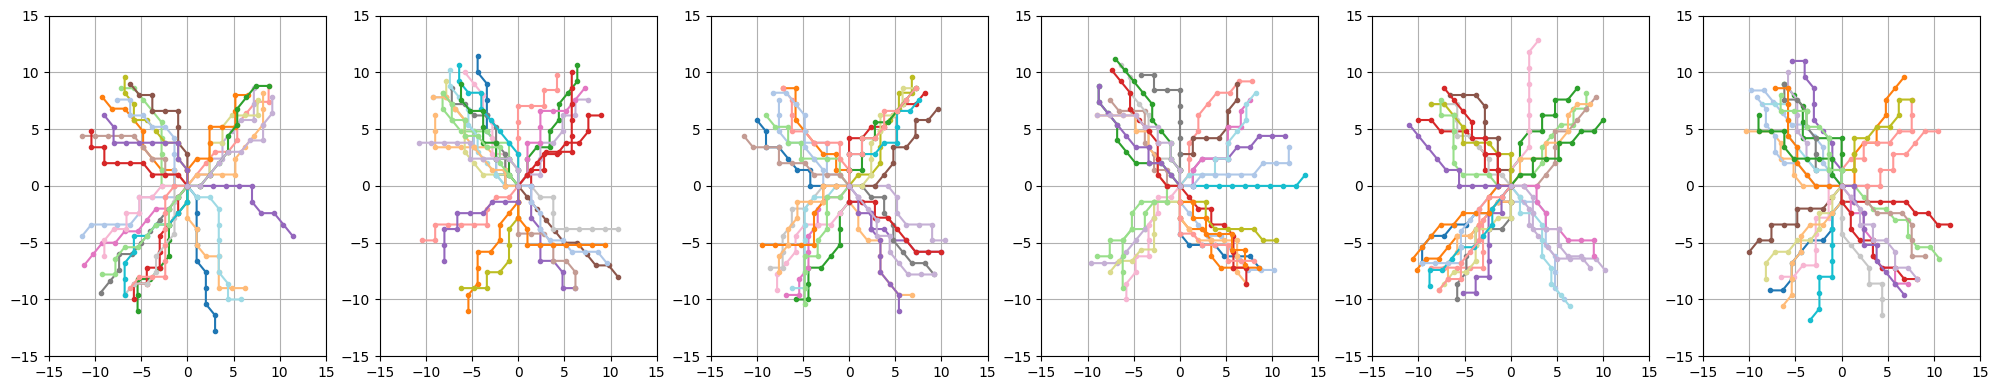

In [5]:
bias1=[[1,1],[1.4,0],[0,1.4]]
bias2=[[-1,1],[-1.4,0],[0,1.4]]
bias3=[[1,-1],[1.4,0],[0,-1.4]]
bias4=[[-1,-1],[-1.4,0],[0,-1.4]]

tip=30

def move(nturn,iloc):
    hist=[iloc]
    locx=iloc[0]
    locy=iloc[1]
    bias=random.choice([bias1,bias2,bias3,bias4])
    for n in range(1,nturn+1):
        travel=random.choice(bias)
        locx+=travel[0]
        locy+=travel[1]
        hist.append([locx,locy])
    return np.array(hist)

fig, axs = plt.subplots(1,6,figsize=(20,4))
colors = plt.cm.tab20.colors

for i in range(0,6):

    for k in range(0,tip):
        hist=move(10,[0,0])
        if k<20:
            axs[i].plot(hist[:,0],hist[:,1],c=colors[k],marker='.')
        elif k>20:
            axs[i].plot(hist[:,0],hist[:,1],c=colors[k-20],marker='.')
    
    axs[i].grid(True)
    axs[i].set_xlim(-15, 15)
    axs[i].set_ylim(-15, 15)

plt.tight_layout()

Notice that distribution of the trajectories follows the expectation value as we increase the number of the tips. This is expected as we are basically using biased random walkers!

--------------------------------------
Before we move on to the real simulation, let us finalize the details of our model. In general, we can classify (for now) our modelling concerns to three main questions:

1. How does each *tip* evolve as it expands out?

    + At each step, with some probability: 
        + survive: continue with the same speed
        + die: stop
        + split: a new tip emerges from the splitting point.
    + What happens when a tip splits?

        + It has been observed that tendrils tend to avoid each other. However, the tips we use here are not exactly the tendrils. They act as scouting elements of the colony. So in our case, rest of the colony follows the trajectories created by the tips, and overlapping tip trajectories give rise to the tendrils of the colony.
        + It would be highly physically relevant to assume that the speed of the splitted tips is reduced and the new tip continues its motion approximately radially outward. As expected, this is due to the conservation of momentum.
    + Every *tip* starts with the same speed, but speed is subject to change based on nutrient distribution.

2. What are the external effects (such as nutrients, antibiotic or another competing colony!)?

    + We just consider the nutrient field for the moment.
    + For instance if antibiotics were considered, death rate would be a function of the antibiotic distribution.

3. How does each *tip* interact with external effects? After all, we are talking about a *living community* that interacts with its own surrounding.

    + Initially, we start with a uniform nutrient distribution.
    + Nutrient rich: increased speed and splitting rate -> Will be covered in Parameter Sweep Section
    + Nutrient poor: decreased speed and increased death rate.
    + We do not consider the attraction towards nutrient rich regions, but tips going towards the poor regions are penalized with an increase in their death probability.

**3. Simulation Algorithm & Inital Results**

In this section, we implement model assumptions and constraints to our naive code we have started with.

In [17]:
import random
import numpy as np 
import matplotlib.pyplot as plt

class config:
    bias_list=[[[1,1],[1.41,0],[0,1.41]],[[-1,1],[-1.41,0],[0,1.41]],[[1,-1],[1.41,0],[0,-1.41]],[[-1,-1],[-1.41,0],[0,-1.41]]]
    def __init__(self,tip_number):
        self.tipn=tip_number


class tip_state:

    def __init__(self,survival_rate=0.75,splitting_rate=0.15):
        self.S=survival_rate
        self.Sp=splitting_rate

    def distribute(self,scale,S,Sp):

        if scale<1:
            S_new=S*scale
            Sp_new=Sp*scale
            
        elif scale>=1:
            S_new=S
            Sp_new=Sp*scale

        return [S_new,Sp_new]
    
    def survival(self):
        outcomes=['S','D','Sp']
        weights=[self.S,1-self.S-self.Sp,self.Sp]
        return random.choices(outcomes,weights,k=1)[0]
    
    def branch_penalty(self,loc,branch_pt,hist):
        if len(branch_pt)>0:
            index=[]
            for pt in branch_pt: 
                index.append(hist.index(pt))

            if hist.index(loc)>= max(index):
                return 0.75
            else :
                return 1
        else:
            return 1       

    def daughter_bias(self,locbp,loci,locf):
        p1=locf-loci
        p2=locf-locbp
        theta1= np.arctan2(p1[1],p1[0])
        theta2= np.arctan2(p2[1],p2[0])

        rad=p2/np.linalg.norm(p2)

        if theta1 >= theta2:
            perp=np.array([-rad[1],rad[0]])
            diag= (rad + perp)/(np.linalg.norm(rad+perp))
        elif theta2 > theta1:
            perp=np.array([rad[1],-rad[0]])
            diag= (rad + perp)/(np.linalg.norm(rad+perp))
        
        dbias=[perp*1.41*0.75,diag*0.75]

        return [[dir.tolist() for dir in dbias]]


class environment:

    def __init__(self,nutrient_dist):
        self.ntype=nutrient_dist


    def nutrient(self,loc):
        if self.ntype=='uniform':
            return 1
        
        elif self.ntype =='red': #radial exponential decay
            radial_dist=np.sqrt(loc[0]**2+loc[1]**2)
            decay=np.exp(-radial_dist/20)
            return decay
        
        elif self.ntype =='half-plane':

            if loc[1]>0:
                return 0.5

            if loc[1]<=0:
                return 1.5
            
    def scale(self,n,base,k):
        raw = 1 / (1 + np.exp(-k * (n/base - 1)))
        f_at_zero = 1 / (1 + np.exp(k))      
        f_at_ref  = 0.5                    
        return (raw - f_at_zero) / (f_at_ref - f_at_zero)



def move(nturn, iloc, bias_list,state,ext):

    #:Record keeping for the motion of the tip
    hist=[iloc]
    sppoint=[]
    deathcount=[]
    survival_hist=[]
    locx=iloc[0]
    locy=iloc[1]
    bias=random.choice(bias_list)
    base_S=state.S
    base_Sp=state.Sp

    #:First Round starts with "Survive"
    travel=random.choice(bias)
    locx+=travel[0]
    locy+=travel[1]
    hist.append([locx,locy])
    survival_hist.append('S')

    #: Rest is drawn from a probability distribution
    for n in range(1,nturn+1):

        travel=random.choice(bias)
        nutrient_scale= ext.scale(ext.nutrient(hist[-1]),1,3)
        state.S = state.distribute(nutrient_scale,base_S,base_Sp)[0]
        state.Sp = state.distribute(nutrient_scale,base_S,base_Sp)[1]
        status=state.survival()
        survival_hist.append(status)
        
        if status=='S':
            penalty=state.branch_penalty(hist[-1],sppoint,hist)*nutrient_scale
            locx+=travel[0]*penalty
            locy+=travel[1]*penalty
            hist.append([locx,locy])

        elif status =='Sp':
            sppoint.append(hist[-1])
            locx+=travel[0]*0.75*nutrient_scale
            locy+=travel[1]*0.75*nutrient_scale
            hist.append([locx,locy])

        elif status =='D':
            deathcount.append(hist[-1])
            break
    return {"trajectory": np.array(hist), "branching_pt": np.array(sppoint),"death": np.array(deathcount) ,"survival hist": survival_hist}


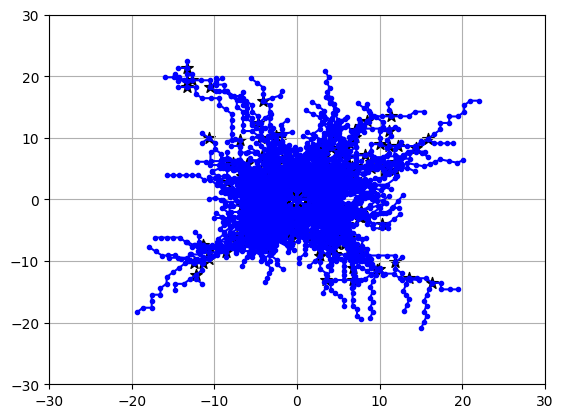

In [62]:
random.seed(40)
np.random.seed(40)
cfg=config(500)
ext=environment('uniform')

tip_record=[]
branch_record=[]
m_turns=30

#:Creating the tips
for k in range(0,cfg.tipn):
    state=tip_state(0.6,0.2)
    tip=move(m_turns,[0,0], cfg.bias_list,state,ext)
    tip_record.append(tip)

#: Branch motion
for tp in tip_record:
    if len(tp['branching_pt'])>0:
        for bpt in tp['branching_pt']:
            state=tip_state(0.7,0)
            bp_index=tp['trajectory'].tolist().index(bpt.tolist())

            remturn= m_turns-bp_index
            loc_init=bpt
            parent_init=tp['trajectory'][0]
            parent_fin=tp['trajectory'][-1]
            daughter_branch = move(remturn, loc_init, state.daughter_bias(loc_init,parent_init,parent_fin),state,ext)
            branch_record.append(daughter_branch)
    
colony_record=tip_record+branch_record
#: Visualization
for tp in colony_record:
    hist=tp["trajectory"]
    branch=tp["branching_pt"]
    plt.plot(hist[:,0],hist[:,1],c='blue',marker='.')
    if len(branch)>0:
        plt.scatter(branch[:,0],branch[:,1],c='black',marker='*', s=75)
    
plt.grid(True)
plt.xlim(-30,30);
plt.ylim(-30,30);


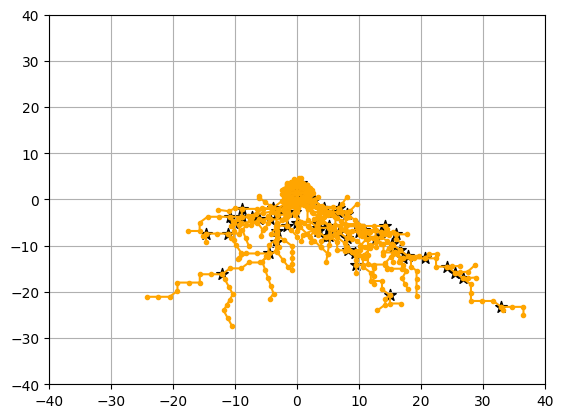

In [25]:
random.seed(41)
np.random.seed(41)
cfg=config(500)
ext=environment('half-plane')

tip_record=[]
branch_record=[]
birthp=[0,1.5]
m_turns=30

#:Creating the tips
for k in range(0,cfg.tipn):
    state=tip_state(0.6,0.2)
    tip=move(m_turns,birthp, cfg.bias_list,state,ext)
    tip_record.append(tip)

#: Branch motion
for tp in tip_record:
    if len(tp['branching_pt'])>0:
        for bpt in tp['branching_pt']:
            state=tip_state(0.7,0)
            bp_index=tp['trajectory'].tolist().index(bpt.tolist())

            remturn= m_turns-bp_index
            loc_init=bpt
            parent_init=tp['trajectory'][0]
            parent_fin=tp['trajectory'][-1]
            daughter_branch = move(remturn, loc_init, state.daughter_bias(loc_init,parent_init,parent_fin),state,ext)
            branch_record.append(daughter_branch)
    
colony_record=tip_record+branch_record
#: Visualization
for tp in colony_record:
    hist=tp["trajectory"]
    branch=tp["branching_pt"]
    plt.plot(hist[:,0],hist[:,1],c='orange',marker='.')
    if len(branch)>0:
        plt.scatter(branch[:,0],branch[:,1],c='black',marker='*', s=75)
    
plt.grid(True)
plt.xlim(-40,40);
plt.ylim(-40,40);

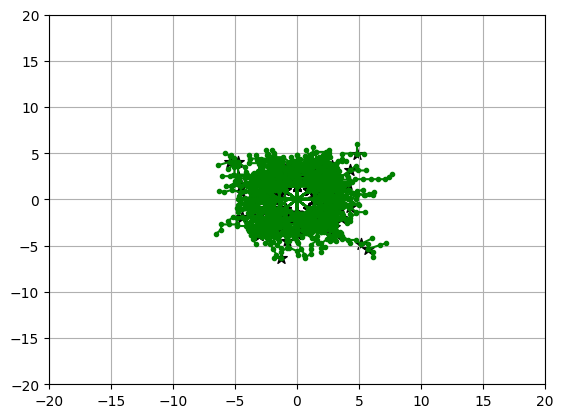

In [23]:
random.seed(41)
np.random.seed(41)
cfg=config(500)
ext=environment('red')

tip_record=[]
branch_record=[]
birthp=[0,0]
m_turns=50

#:Creating the tips
for k in range(0,cfg.tipn):
    state=tip_state(0.6,0.2)
    tip=move(m_turns,birthp, cfg.bias_list,state,ext)
    tip_record.append(tip)

#: Branch motion
for tp in tip_record:
    if len(tp['branching_pt'])>0:
        for bpt in tp['branching_pt']:
            state=tip_state(0.7,0)
            bp_index=tp['trajectory'].tolist().index(bpt.tolist())

            remturn= m_turns-bp_index
            loc_init=bpt
            parent_init=tp['trajectory'][0]
            parent_fin=tp['trajectory'][-1]
            daughter_branch = move(remturn, loc_init, state.daughter_bias(loc_init,parent_init,parent_fin),state,ext)
            branch_record.append(daughter_branch)
    
colony_record=tip_record+branch_record
#: Visualization
for tp in colony_record:
    hist=tp["trajectory"]
    branch=tp["branching_pt"]
    plt.plot(hist[:,0],hist[:,1],c='green',marker='.')
    if len(branch)>0:
        plt.scatter(branch[:,0],branch[:,1],c='black',marker='*', s=75)
    
plt.grid(True)
plt.xlim(-20,20);
plt.ylim(-20,20);

**4. Monte Carlo Experiments**

**4.1 Mean Radius and Variance**

For our first experiment, we consider the mean radius for the colony for each number of turns in a uniform nutrient backgorund.

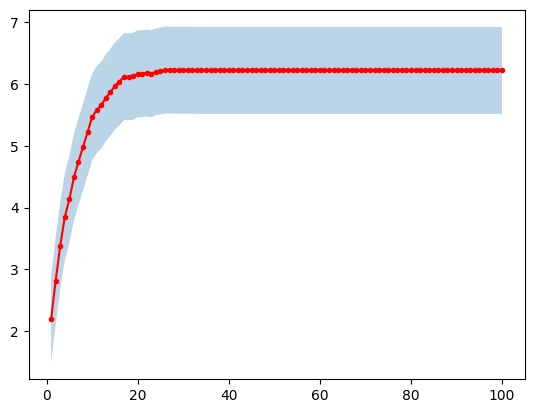

In [99]:
def colony(m_turns):

    random.seed(38)
    np.random.seed(38)
    cfg=config(500)
    ext=environment('uniform')

    tip_record=[]
    branch_record=[]


    #:Creating the tips
    for k in range(0,cfg.tipn):
        state=tip_state(0.6,0.2)
        tip=move(m_turns,[0,0], cfg.bias_list,state,ext)
        tip_record.append(tip)

    #: Branch motion
    for tp in tip_record:
        if len(tp['branching_pt'])>0:
            for bpt in tp['branching_pt']:
                state=tip_state(0.7,0)
                bp_index=tp['trajectory'].tolist().index(bpt.tolist())

                remturn= m_turns-bp_index
                loc_init=bpt
                parent_init=tp['trajectory'][0]
                parent_fin=tp['trajectory'][-1]
                daughter_branch = move(remturn, loc_init, state.daughter_bias(loc_init,parent_init,parent_fin),state,ext)
                branch_record.append(daughter_branch)

    colony_record=tip_record+branch_record

    radius=[]
    xsum=[]
    ysum=[]
    
    for tips in colony_record:
        r=tips['trajectory'][-1]
        radius.append(np.linalg.norm(r))

    for tips in colony_record:
        hist=tips['trajectory']
        xsum.extend(hist[:,0])
        ysum.extend(hist[:,1])
    
    return [np.mean(radius,axis=0),xsum,ysum]

rcolony=[]
std=[]
all_x = []
all_y = []

for n in range(1,101):
    rcolony.append(colony(n)[0])
    all_x.extend(colony(n)[1])
    all_y.extend(colony(n)[2])

time=np.linspace(1,100,100)
mean_rad=np.array(rcolony)
std_rad=np.std(mean_rad)
plt.plot(time,mean_rad,c='red',marker='.')
plt.fill_between(
    time,
    mean_rad-std_rad,
    mean_rad+std_rad,
    alpha=0.3
)


This is exactly the behaviour we expect from mean colony radius!

**4.2 Visualising the Colony**

In this section, we consider two methods: density map and colony shape. We have already accumulated the . Let's start with the density map:

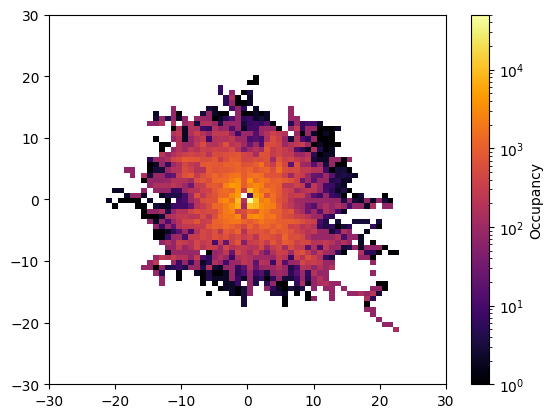

In [129]:
plt.hist2d(all_x, all_y, bins=50,cmap='inferno',norm='log')
plt.colorbar(label="Occupancy")
plt.xlim(-30,30);
plt.ylim(-30,30);

Our density map makes sense as we basically stack all colony shapes on top of each other for the turn numbers from 0 to 1. Finally, let us provide the colony shape evolution.

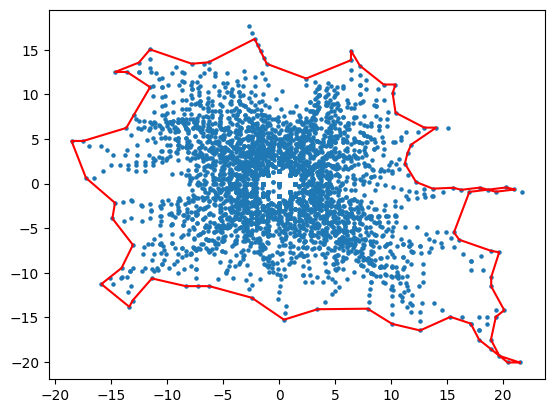

In [166]:
from scipy.spatial import ConvexHull
import alphashape

alpha=0.4
nturns=30

pts = np.column_stack((colony(nturns)[1], colony(nturns)[2]))
hull = ConvexHull(pts)
hull2=alphashape.alphashape(pts, alpha)


plt.scatter(pts[:,0], pts[:,1], s=5)


if hull2.geom_type == "Polygon":
    x, y = hull2.exterior.xy
    plt.plot(x, y, 'r-')

# CASE 2: multiple polygons
elif hull2.geom_type == "MultiPolygon":
    for poly in hull2.geoms:
        x, y = poly.exterior.xy
        plt.plot(x, y, 'r-')

plt.show()

It appears that our `alphashape` method does not do a very good job. However, our colony shape reveals that fingerings emerge as we increase the number of turns.

**5. Parameter Sweep**

We first start investigating the effect of number of turns the tips are allowed to move while in a homogeneous nutrient distribution. The trend we observe is quite remarkable: the evolution of colony shape starts from an approximate axial symmetry and goes towards emergence of tendrils as the number of turns are increased!

In [42]:
import ipywidgets as widget
from ipywidgets import interact

def uniform_sweep(m_turns):

    random.seed(40)
    np.random.seed(40)
    cfg=config(500)
    ext=environment('uniform')

    tip_record=[]
    branch_record=[]


    #:Creating the tips
    for k in range(0,cfg.tipn):
        state=tip_state(0.6,0.2)
        tip=move(m_turns,[0,0], cfg.bias_list,state,ext)
        tip_record.append(tip)

    #: Branch motion
    for tp in tip_record:
        if len(tp['branching_pt'])>0:
            for bpt in tp['branching_pt']:
                state=tip_state(0.7,0)
                bp_index=tp['trajectory'].tolist().index(bpt.tolist())

                remturn= m_turns-bp_index
                loc_init=bpt
                parent_init=tp['trajectory'][0]
                parent_fin=tp['trajectory'][-1]
                daughter_branch = move(remturn, loc_init, state.daughter_bias(loc_init,parent_init,parent_fin),state,ext)
                branch_record.append(daughter_branch)
        
    colony_record=tip_record+branch_record
    #: Visualization
    for tp in colony_record:
        hist=tp["trajectory"]
        branch=tp["branching_pt"]
        plt.plot(hist[:,0],hist[:,1],c='blue',marker='.')
        if len(branch)>0:
            plt.scatter(branch[:,0],branch[:,1],c='black',marker='*', s=75)
    plt.text(20, 20, f"n = {m_turns}", fontsize=12)    
    plt.grid(True)
    plt.xlim(-30,30);
    plt.ylim(-30,30);

slider=widget.IntSlider(value=5,min=5,max=50,step=5)

interact(uniform_sweep,m_turns=slider)

interactive(children=(IntSlider(value=5, description='m_turns', max=50, min=5, step=5), Output()), _dom_classe…

<function __main__.uniform_sweep(m_turns)>

Next, we consider the highly anisotropic distribution we refer as half-plane. In this, we will cover a 2-parameter space. First, we want to change the location of the initial colony. Second, the number of turns again.

In [ ]:
def halfplane_sweep(birthp,m_turns):

    random.seed(41)
    np.random.seed(41)
    cfg=config(500)
    ext=environment('half-plane')

    tip_record=[]
    branch_record=[]

    #:Creating the tips
    for k in range(0,cfg.tipn):
        state=tip_state(0.6,0.2)
        tip=move(m_turns,[0,birthp], cfg.bias_list,state,ext)
        tip_record.append(tip)

    #: Branch motion
    for tp in tip_record:
        if len(tp['branching_pt'])>0:
            for bpt in tp['branching_pt']:
                state=tip_state(0.7,0)
                bp_index=tp['trajectory'].tolist().index(bpt.tolist())

                remturn= m_turns-bp_index
                loc_init=bpt
                parent_init=tp['trajectory'][0]
                parent_fin=tp['trajectory'][-1]
                daughter_branch = move(remturn, loc_init, state.daughter_bias(loc_init,parent_init,parent_fin),state,ext)
                branch_record.append(daughter_branch)
        
    colony_record=tip_record+branch_record
    #: Visualization
    for tp in colony_record:
        hist=tp["trajectory"]
        branch=tp["branching_pt"]
        plt.plot(hist[:,0],hist[:,1],c='orange',marker='.')
        if len(branch)>0:
            plt.scatter(branch[:,0],branch[:,1],c='black',marker='*', s=75)
        
    plt.grid(True)
    plt.xlim(-70,70);
    plt.ylim(-70,70);

slider1=widget.FloatSlider(value=0,min=-5,max=5,step=0.5)
slider2=widget.IntSlider(value=5,min=5,max=70,step=5)

interact(halfplane_sweep,birthp=slider1,m_turns=slider2)

interactive(children=(FloatSlider(value=0.0, description='birthp', max=5.0, min=-5.0, step=0.5), IntSlider(val…

<function __main__.halfplane_sweep(birthp, m_turns)>

Lastly, we consider the Radial Exponential Decay case. This would not be a realistic nutrient distribution, but it provides a good insight when there are external agents preventing colony to expand.

In [ ]:
import ipywidgets as widget
from ipywidgets import interact

def red_sweep(m_turns):

    random.seed(42)
    np.random.seed(42)
    cfg=config(500)
    ext=environment('red')

    tip_record=[]
    branch_record=[]


    #:Creating the tips
    for k in range(0,cfg.tipn):
        state=tip_state(0.6,0.2)
        tip=move(m_turns,[0,0], cfg.bias_list,state,ext)
        tip_record.append(tip)

    #: Branch motion
    for tp in tip_record:
        if len(tp['branching_pt'])>0:
            for bpt in tp['branching_pt']:
                state=tip_state(0.7,0)
                bp_index=tp['trajectory'].tolist().index(bpt.tolist())

                remturn= m_turns-bp_index
                loc_init=bpt
                parent_init=tp['trajectory'][0]
                parent_fin=tp['trajectory'][-1]
                daughter_branch = move(remturn, loc_init, state.daughter_bias(loc_init,parent_init,parent_fin),state,ext)
                branch_record.append(daughter_branch)
        
    colony_record=tip_record+branch_record
    #: Visualization
    for tp in colony_record:
        hist=tp["trajectory"]
        branch=tp["branching_pt"]
        plt.plot(hist[:,0],hist[:,1],c='green',marker='.')
        if len(branch)>0:
            plt.scatter(branch[:,0],branch[:,1],c='black',marker='*', s=75)
       
    plt.grid(True)
    plt.xlim(-20,20);
    plt.ylim(-20,20);

slider=widget.IntSlider(value=5,min=5,max=30,step=5)

interact(red_sweep,m_turns=slider)

interactive(children=(IntSlider(value=5, description='m_turns', max=30, min=5, step=5), Output()), _dom_classe…

<function __main__.red_sweep(m_turns)>

**6. Key Findings & Interpretation**

*Key Findings*
- Symmetry-constrained biased random walks reproduce branching-like colony morphologies.
- Nutrient anisotropy strongly affects expansion direction and density.
- Environmental scaling alters both branching frequency and colony compactness.

One interpretation of our findings is that colony does not exactly behave as we would expect when in a uniform nutrient background. This actually has to do with how we define the motion of individual tips. Although in the small turn limit we recover the colony behaviour, large turn limit seems to be in the regime between the colony behavior and the expect value of the tip motion. This is probably due to the fact that we allow tips to die and split.

**7. Future Directions**

It must be clear at this point that the topic of colony morphology and its evolution is so vast that this notebook is not sufficient to cover every corner. However, there are some natural extension directions for this project:

1. For the nutrient field, we must provide a depletion mechanism. We expect this to have a non-negligible effect on the density of tips.
2. Understanding the effect of in-colony competition and tip-tip interactions
3. Investigation of variety of external effects such as antibiotic environments carries significance. It appears that our framework responds well and meaningfully to effects that can either boost or suppress the colony expansion.
4. Understanding the transition from individual bacteries to colony-level behvaiour
5. Calibration against experimental data


**8. Acknowledgements**

We would like to thank Emrah Simsek for the helpful conversations and especially for bringing this topic to our attention. This project was developed as an independent exploratory modeling study to demonstrate stochastic simulation, scientific computing, and emergent behavior analysis.